<a href="https://colab.research.google.com/github/Arjunn-Arvindhan/Daa---lab/blob/main/Exp%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np

# Set a professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

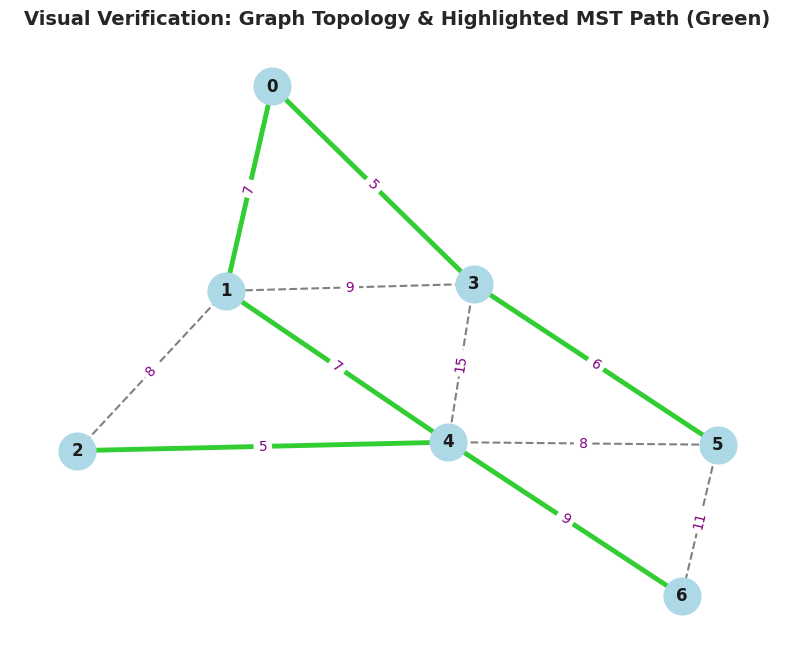

In [2]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, x):
        if self.parent[x] != x: self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry: return False
        self.parent[ry] = rx
        return True

def kruskal(n, edges):
    edges.sort()
    uf = UnionFind(n)
    mst = []
    for w, u, v in edges:
        if uf.union(u, v):
            mst.append((u, v))
            if len(mst) == n - 1: break
    return mst

# Define the graph architecture from the manual
n = 7
edges = [
    (7, 0, 1), (5, 0, 3), (8, 1, 2), (9, 1, 3),
    (7, 1, 4), (5, 2, 4), (15, 3, 4), (6, 3, 5),
    (8, 4, 5), (9, 4, 6), (11, 5, 6)
]

# Run layout computation
mst_edges = kruskal(n, edges)

# Build graphical node-edge layout
G = nx.Graph()
for w, u, v in edges:
    G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 8))

# Draw baseline elements
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
nx.draw_networkx_labels(G, pos, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=1.5, edge_color='gray', style='dashed')

# Graphically map and overlay the computed MST path
nx.draw_networkx_edges(G, pos, edgelist=mst_edges, width=3.5, edge_color='limegreen')

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='purple')

plt.title("Visual Verification: Graph Topology & Highlighted MST Path (Green)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()